In [17]:
import numpy as np
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.optim as optim
import torch
import torch.nn as nn
import matplotlib.patches as patches

from torch.utils.data import Dataset, DataLoader



In [18]:
# GPU monitoring and optimization utilities
def print_gpu_info():
    """Print detailed GPU information"""
    if torch.cpu.is_available():
        print(f"GPU: {torch.cpu.get_device_name(0)}")
        print(f"Total Memory: {torch.cpu.get_device_properties(0).total_memory / 1e9:.2f} GB")
        print(f"Allocated: {torch.cpu.memory_allocated(0) / 1e9:.2f} GB")
        print(f"Cached: {torch.cpu.memory_reserved(0) / 1e9:.2f} GB")
    else:
        print("cpu not available")

def find_optimal_batch_size(model, sample_feats, device="cpu", start_batch=512, max_batch=8192):
    """
    Find the maximum batch size that fits in GPU memory.
    Use this if you get OOM (Out of Memory) errors.
    """
    if not torch.cpu.is_available():
        return start_batch
    
    model.eval()
    batch_size = start_batch
    
    while batch_size <= max_batch:
        try:
            # Clear cache
            torch.cpu.empty_cache()
            
            # Test batch
            test_batch = sample_feats[:batch_size].to(device)
            with torch.no_grad():
                _ = model(test_batch)
            
            # If successful, try next size
            batch_size *= 2
            del test_batch
            torch.cpu.empty_cache()
        except RuntimeError as e:
            if "out of memory" in str(e):
                torch.cpu.empty_cache()
                optimal = batch_size // 2
                print(f"Optimal batch size: {optimal}")
                return optimal
            else:
                raise e
    
    print(f"Optimal batch size: {batch_size // 2}")
    return batch_size // 2

print_gpu_info()

AttributeError: module 'torch.cpu' has no attribute 'get_device_name'

In [19]:
# -----------------------
# 1. Generate diffusion data (Dirichlet BC)
# -----------------------
def diffusion_solver_dirichlet(u0, nu=0.01, dx=1/128, dt=1e-4, n_steps=2000):
    """Explicit finite-difference solver for 1D diffusion (Dirichlet BCs u(0,t)=u(1,t)=0)."""
    u = u0.copy()
    Nx = len(u)
    traj = [u.copy()]
    for _ in range(n_steps):
        un = u.copy()

        # discrete Laplacian on interior points only (no np.roll)
        lap = (un[2:] - 2*un[1:-1] + un[:-2]) / dx**2
        u[1:-1] = un[1:-1] + nu * dt * lap

        # Dirichlet boundaries
        u[0] = 0.0
        u[-1] = 0.0

        traj.append(u.copy())
    return np.stack(traj)  # shape (T, Nx)

def generate_diffusion_data(Nx=128, nu=0.01, dt=1e-4, n_steps=4000):
    dx = 1.0 / (Nx - 1)
    x = np.linspace(0, 1, Nx)

    # initial condition compatible with Dirichlet BC
    u0 = np.sin(2*np.pi * x)   # = 0 at x=0 and x=1

    data = diffusion_solver_dirichlet(u0, nu, dx, dt, n_steps)
    return x, data  # data[t, x]

# -----------------------
# 3. Training setup
# -----------------------
Nx =500
dt0 = 1e-4
nu = 0.01
n_steps = 20000

x, data = generate_diffusion_data(Nx, nu, dt0, n_steps)


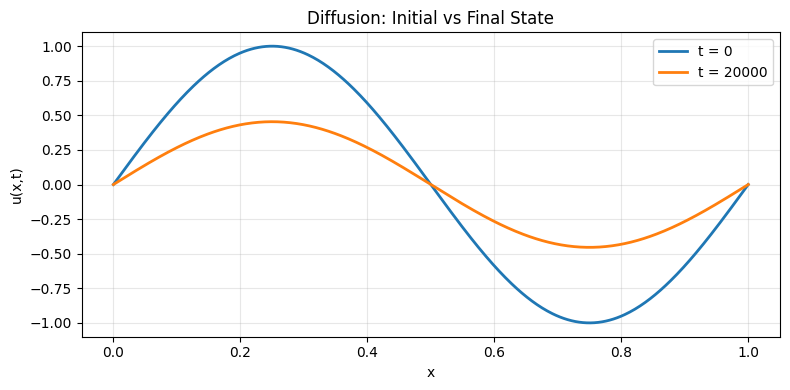

In [20]:
t_plot = n_steps  # or whatever final index you used

plt.figure(figsize=(8,4))
plt.plot(x, data[0], label="t = 0", linewidth=2)
plt.plot(x, data[t_plot], label=f"t = {t_plot}", linewidth=2)
plt.title("Diffusion: Initial vs Final State")
plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [5]:
def sample_one_B(u,R=5, k=5, max_tries=50, u_scale=None):
    """
    Sample a single Scheme-B training example using an index-space circle.
    
    Geometry matches inference:
        (t - t0)^2 + (x - x0)^2 <= R^2

    Returns:
        feats_flat: (k*3,) with [dt_scaled, dx_scaled, u_scaled]
        target: scalar normalized u(t0,x0)
    """
    Nt, Nx = u.shape

    if u_scale is None:
        u_scale = np.max(np.abs(u)) + 1e-8

    for _ in range(max_tries):

        # ---- 1. sample random center ----
        t0 = np.random.randint(0, Nt)
        x0 = np.random.randint(0, Nx)

        # ---- 2. compute bounds for circle ----
        t_min = max(0, t0 - R)
        t_max = min(Nt - 1, t0 + R)
        x_min = max(0, x0 - R)
        x_max = min(Nx - 1, x0 + R)

        # ---- 3. collect candidate neighbors ----
        cand = []
        for t in range(t_min, t_max + 1):
            dt = t - t0
            dt2 = dt*dt
            if dt2 > R*R:   # quick pruning by rows
                continue

            for x in range(x_min, x_max + 1):
                if t == t0 and x == x0:
                    continue
                dx = x - x0
                if dt2 + dx*dx <= R*R:
                    cand.append((t, x))

        if len(cand) < k:
            continue  # try new center

        # ---- 4. pick k random neighbors ----
        cand = np.array(cand)
        idx = np.random.choice(len(cand), size=k, replace=False)
        neigh = cand[idx]

        # ---- 5. build feature vector ----
        feats = []
        for (tn, xn) in neigh:
            dt_scaled = (t0 - tn) / R   # scale into [-1,1]
            dx_scaled = (x0 - xn) / R
            u_scaled = u[tn, xn] / u_scale
            feats.append([dt_scaled, dx_scaled, u_scaled])

        feats = np.array(feats, dtype=np.float32).reshape(-1)
        target = np.float32(u[t0, x0] / u_scale)
        return feats, target

    raise RuntimeError("Failed to sample B-example; try changing R/k.")


In [21]:
class BDataset(Dataset):
    """
    Scheme-B dataset:
    - u: PDE solution on fine grid, shape (Nt, Nx)
    - N_samples: number of samples to generate on the fly
    """
    def __init__(self, u, N_samples=50000, R=5, k=5, seed=0, pregenerate=False):
        self.u = u
        self.N_samples = N_samples
        self.R = R
        self.k = k
        self.rng = np.random.RandomState(seed)
        
        # fix global u-scale for normalization
        self.u_scale = np.max(np.abs(u)) + 1e-8
        
        # Pre-generate all samples for faster GPU utilization
        self.pregenerate = pregenerate
        if pregenerate:
            print(f"Pre-generating {N_samples} samples...")
            self.feats_list = []
            self.targets_list = []
            for i in range(N_samples):
                if (i + 1) % 10000 == 0:
                    print(f"  Generated {i+1}/{N_samples} samples")
                np.random.set_state(self.rng.get_state())
                feats, target = sample_one_B(self.u, R=self.R, k=self.k, u_scale=self.u_scale)
                self.rng.random_sample()
                self.feats_list.append(feats)
                self.targets_list.append(target)
            # Convert to tensors for faster access
            self.feats_tensor = torch.from_numpy(np.array(self.feats_list, dtype=np.float32))
            self.targets_tensor = torch.from_numpy(np.array(self.targets_list, dtype=np.float32))
            print("Pre-generation complete!")

    def __len__(self):
        return self.N_samples
    
    def __getitem__(self, idx):
        if self.pregenerate:
            # Fast path: return pre-generated data
            return self.feats_tensor[idx], self.targets_tensor[idx]
        else:
            # Slow path: generate on the fly
            np.random.set_state(self.rng.get_state())
            feats, target = sample_one_B(self.u, R=self.R, k=self.k, u_scale=self.u_scale)
            self.rng.random_sample()
            return torch.from_numpy(feats), torch.tensor(target, dtype=torch.float32)


In [22]:
class MLPIntegrator(nn.Module):
    def __init__(self, k=5, hidden=512, num_layers=6):
        super().__init__()
        in_dim = k * 3
        layers = []
        layers.append(nn.Linear(in_dim, hidden))
        layers.append(nn.ReLU())
        layers.append(nn.BatchNorm1d(hidden))  # Add batch norm for better training
        
        for _ in range(num_layers - 2):
            layers.append(nn.Linear(hidden, hidden))
            layers.append(nn.ReLU())
            layers.append(nn.BatchNorm1d(hidden))
            layers.append(nn.Dropout(0.1))  # Add dropout for regularization
        
        layers.append(nn.Linear(hidden, 1))
        self.net = nn.Sequential(*layers)
    
    def forward(self, x):
        # x: (batch, in_dim)
        return self.net(x).squeeze(-1)


In [ ]:
def train_integrator_B(u, epochs=50, batch_size=2048, k=5, R=5,
                       N_samples=100000, lr=1e-3, hidden=512, num_layers=6, 
                       device="cpu", use_amp=True, pregenerate=True):
    """
    Train the MLP integrator on Scheme-B data.
    
    u: numpy array (Nt, Nx) with PDE solution
    use_amp: Use Automatic Mixed Precision (FP16) for faster training
    pregenerate: Pre-generate all samples for faster data loading
    """
    device = torch.device(device)
    
    # Pre-generate dataset to avoid CPU bottleneck during training
    print("Setting up dataset...")
    dataset = BDataset(u, N_samples=N_samples, R=R, k=k, pregenerate=pregenerate)
    
    # Optimize DataLoader based on whether data is pre-generated
    # Pre-generated data doesn't need many workers (data is already in memory)
    if pregenerate:
        num_workers = 0  # No workers needed - data is already in memory
        pin_memory = True
        persistent_workers = False
        prefetch_factor = None
        print("Using pre-generated data: num_workers=0 for minimal overhead")
    else:
        num_workers = min(8, torch.get_num_threads())
        pin_memory = True
        persistent_workers = True if num_workers > 0 else False
        prefetch_factor = 4 if num_workers > 0 else 2
        print(f"Using on-the-fly generation: num_workers={num_workers}")
    
    loader = DataLoader(
        dataset, 
        batch_size=batch_size, 
        shuffle=True, 
        num_workers=num_workers, 
        pin_memory=pin_memory,
        persistent_workers=persistent_workers,
        prefetch_factor=prefetch_factor
    )
    
        # --- Model setup (fixed version) ---
    model = MLPIntegrator(k=k, hidden=hidden, num_layers=num_layers).to(device)

    # torch.compile disabled because Inductor breaks during warmup (AMP + BN + backward)
    print("Skipping torch.compile (Inductor unstable on this model)")

    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=5, verbose=False)
    loss_fn = nn.MSELoss()

    # Mixed precision training scaler
    if use_amp and device.type == 'cpu':
        try:
            scaler = torch.amp.GradScaler('cpu')
        except:
            scaler = torch.cpu.amp.GradScaler()
    else:
        scaler = None

    print(f"Training on device: {device}")
    print(f"Model parameters: {sum(p.numel() for p in  model.parameters()):,}")
    print(f"Training samples: {N_samples:,}")
    print(f"Batch size: {batch_size}")
    print(f"Mixed precision (AMP): {use_amp}")
    print(f"DataLoader workers: {num_workers}")

    
    # GPU monitoring function
    def get_gpu_stats():
        if device.type == 'cpu':
            mem_allocated = torch.cpu.memory_allocated(0) / 1e9
            mem_reserved = torch.cpu.memory_reserved(0) / 1e9
            mem_total = torch.cpu.get_device_properties(0).total_memory / 1e9
            return f"GPU Mem: {mem_allocated:.2f}/{mem_reserved:.2f}/{mem_total:.2f} GB"
        return ""
    
    # Proper GPU warmup with actual model forward/backward
    print("\nWarming up GPU with model...")
    if device.type == 'cpu':
        model.train()
        warmup_batch = next(iter(loader))
        feats_warmup = warmup_batch[0].to(device, non_blocking=True)
        target_warmup = warmup_batch[1].to(device, non_blocking=True)
        
        # Do a few warmup iterations
        for _ in range(3):
            opt.zero_grad()
            if use_amp and scaler is not None:
                with torch.amp.autocast(device_type='cpu'):
                    pred = model(feats_warmup)
                    loss = loss_fn(pred, target_warmup)
                scaler.scale(loss).backward()
                scaler.step(opt)
                scaler.update()
            else:
                pred = model(feats_warmup)
                loss = loss_fn(pred, target_warmup)
                loss.backward()
                opt.step()
        torch.cpu.synchronize()
        print("Warmup complete!\n")
    
    import time
    total_batches = len(loader)
    print(f"Total batches per epoch: {total_batches}")
    print("="*60)
    print("Starting training - you should see batch progress below...")
    print("="*60 + "\n")
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        epoch_start = time.time()
        batch_times = []
        
        for batch_idx, (feats, target) in enumerate(loader):
            batch_start = time.time()
            
            feats = feats.to(device, non_blocking=True)
            target = target.to(device, non_blocking=True)
            
            opt.zero_grad()
            
            # Mixed precision forward pass
            if use_amp and scaler is not None:
                with torch.amp.autocast(device_type='cpu'):
                    pred = model(feats)
                    loss = loss_fn(pred, target)
                
                scaler.scale(loss).backward()
                scaler.unscale_(opt)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(opt)
                scaler.update()
            else:
                pred = model(feats)
                loss = loss_fn(pred, target)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                opt.step()
            
            total_loss += loss.item() * feats.size(0)
            batch_time = time.time() - batch_start
            batch_times.append(batch_time)
            
            # Progress indicator every 10 batches or at start/end
            if (batch_idx + 1) % 10 == 0 or batch_idx == 0 or (batch_idx + 1) == total_batches:
                avg_batch_time = np.mean(batch_times[-10:]) if batch_times else batch_time
                samples_per_sec = batch_size / avg_batch_time
                gpu_stats = get_gpu_stats()
                print(f"  Batch {batch_idx+1}/{total_batches} | "
                      f"Loss: {loss.item():.6e} | "
                      f"Speed: {samples_per_sec:.0f} samples/s | "
                      f"{gpu_stats}")
        
        avg_loss = total_loss / len(dataset)
        scheduler.step(avg_loss)
        current_lr = opt.param_groups[0]['lr']
        epoch_time = time.time() - epoch_start
        samples_per_sec = len(dataset) / epoch_time
        avg_batch_time = np.mean(batch_times)
        
        print(f"\n[Epoch {epoch+1}/{epochs}] train MSE = {avg_loss:.6e}, lr = {current_lr:.2e}")
        print(f"  Epoch time: {epoch_time:.2f}s | Speed: {samples_per_sec:.0f} samples/s | "
              f"Avg batch: {avg_batch_time*1000:.1f}ms | {get_gpu_stats()}\n")
    
    return model.to(device), dataset



In [23]:
def eval_integrator_B(model, dataset, N_test=10000, batch_size=4096, device="cpu", use_amp=True):
    device = torch.device(device)
    model.eval()
    
    # fresh test dataset with different seed, pre-generate for speed
    test_ds = BDataset(dataset.u, N_samples=N_test, R=dataset.R, k=dataset.k, seed=123, pregenerate=True)
    num_workers = 0  # Pre-generated data doesn't need workers
    loader = DataLoader(
        test_ds, 
        batch_size=batch_size, 
        shuffle=False, 
        num_workers=num_workers, 
        pin_memory=True
    )
    
    loss_fn = nn.MSELoss()
    total_loss = 0.0
    
    with torch.no_grad():
        for feats, target in loader:
            feats = feats.to(device, non_blocking=True)
            target = target.to(device, non_blocking=True)
            
            if use_amp and device.type == 'cpu':
                with torch.cpu.amp.autocast():
                    pred = model(feats)
                    loss = loss_fn(pred, target)
            else:
                pred = model(feats)
                loss = loss_fn(pred, target)
            
            total_loss += loss.item() * feats.size(0)
    
    avg_loss = total_loss / N_test
    print(f"[Eval B] MSE = {avg_loss:.6e}")
    return avg_loss


In [24]:
# Check GPU availability and monitor utilization
if torch.cpu.is_available():
    print(f"Using GPU: {torch.cpu.get_device_name(0)}")
    print(f"GPU Memory: {torch.cpu.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"cpu Version: {torch.version.cpu}")
    print(f"cuDNN Version: {torch.backends.cudnn.version()}")
    
    # Enable optimizations
    torch.backends.cudnn.benchmark = True  # Optimize for consistent input sizes
    torch.backends.cudnn.deterministic = False  # Allow non-deterministic for speed
else:
    print("Warning: cpu not available, using CPU")

# IMPORTANT: If GPU usage is still low (<20%), try:
# 1. Increase batch_size to 4096, 8192, or even 16384 (4090 has 24GB VRAM)
# 2. The model is relatively small (1M params), so larger batches help utilization
# 3. Monitor with: watch -n 1 nvidia-smi (in another terminal)

model, train_ds = train_integrator_B(
    data,
    epochs=150,           # Increased epochs for better convergence
    batch_size=4096,     # Try larger: 4096, 8192, or 16384 for better GPU utilization
    k=5,
    R=5,
    N_samples=100000,    # Much more samples to cover full 20k time steps
    lr=1e-3,
    hidden=512,          # Larger model (4x increase)
    num_layers=6,       # More layers for better capacity
    device="cpu",
    use_amp=True,        # Enable mixed precision (FP16) for 2x speedup
    pregenerate=True     # Pre-generate all samples to avoid CPU bottleneck
)
eval_integrator_B(model, train_ds, N_test=10000, batch_size=4096, device="cpu")

AttributeError: module 'torch.cpu' has no attribute 'get_device_name'

In [11]:
# Save the trained model
model_save_path = "model_integrator.pth"
torch.save({
    'model_state_dict': model.state_dict(),
    'k': train_ds.k,
    'R': train_ds.R,
 
    'hidden': 512,
    'num_layers': 6,
    'u_scale': train_ds.u_scale,
    'Nx': data.shape[1],
    'Nt': data.shape[0]
}, model_save_path)
print(f"Model saved to {model_save_path}")
print(f"Model size: {sum(p.numel() for p in model.parameters()):,} parameters")

NameError: name 'model' is not defined

In [37]:
def visualize_B_with_prediction(u, model, R=5, k=5, device="cpu"):
    model.eval()
    Nt, Nx = u.shape
    
    # ---- choose random center ----
    t0 = np.random.randint(0, Nt)
    x0 = np.random.randint(0, Nx)
    
    # ---- build the same candidate set as in sample_one_B ----
    t_min = max(0, t0 - R)
    t_max = min(Nt - 1, t0 + R)
    x_min = max(0, x0 - R)
    x_max = min(Nx - 1, x0 + R)

    cand = []
    for t in range(t_min, t_max + 1):
        dt = t - t0
        dt2 = dt * dt
        if dt2 > R * R:
            continue
        for x in range(x_min, x_max + 1):
            if t == t0 and x == x0:
                continue
            dx = x - x0
            if dt2 + dx * dx <= R * R:
                cand.append((t, x))

    cand = np.array(cand)
    if len(cand) < k:
        raise RuntimeError("Not enough neighbors found; try smaller R or different center")

    # ---- pick k neighbors exactly like sampler ----
    idx = np.random.choice(len(cand), size=k, replace=False)
    neigh = cand[idx]  # (k,2) with (t, x)

    # ---- build features exactly like sample_one_B ----
    u_scale = np.max(np.abs(u)) + 1e-8
    feats = []
    for (tn, xn) in neigh:
        dt_scaled = (t0 - tn) / R
        dx_scaled = (x0 - xn) / R
        u_scaled = u[tn, xn] / u_scale
        feats.append([dt_scaled, dx_scaled, u_scaled])
    feats = np.array(feats, dtype=np.float32).reshape(1, -1)  # (1, k*3)

    # ---- predict ----
    feats_torch = torch.from_numpy(feats).to(device)
    with torch.no_grad():
        pred = model(feats_torch).item() * u_scale
    true = u[t0, x0]

    # ---- plot neighborhood ----
    fig, ax = plt.subplots(figsize=(5, 5))

    # circle of radius R in index space (same as training)
    circle = patches.Circle((x0, t0), radius=R, fill=False,
                            edgecolor='blue', linewidth=1.5)
    ax.add_patch(circle)

    # neighbors
    ax.scatter(neigh[:, 1], neigh[:, 0], s=120, label='neighbors')
    for (tn, xn) in neigh:
        ax.plot([x0, xn], [t0, tn], alpha=0.6)

    # target
    ax.scatter([x0], [t0], c='red', s=200, label='target')

    # Zoom so you see the full ball
    pad = 2
    ax.set_xlim(x0 - R - pad, x0 + R + pad)
    ax.set_ylim(t0 + R + pad, t0 - R - pad)  # time upward

    ax.set_xlabel("x (space index)")
    ax.set_ylabel("t (time index, upward)")
    ax.set_title(f"u_true={true:.5f}, u_pred={pred:.5f}, err={(true-pred)/true*100:.5f}%")

    # Make the circle actually look round
    ax.set_aspect("equal", adjustable="box")

    ax.legend()
    plt.tight_layout()
    plt.show()


In [38]:
# Model loading function
def load_integrator_model(model_path, device="cpu"):
    """
    Load a saved integrator model.
    
    Returns:
        model: loaded MLPIntegrator model
        config: dictionary with hyperparameters (k, R, hidden, u_scale, Nx, Nt)
    """
    checkpoint = torch.load(model_path, map_location=device, weights_only=False)
    
    k = checkpoint['k']
    hidden = checkpoint['hidden']
    num_layers = checkpoint.get('num_layers', 6)  # Default to 6 for backward compatibility
    u_scale = checkpoint['u_scale']
    R = checkpoint['R']
    Nx = checkpoint['Nx']
    Nt = checkpoint['Nt']
    
    model = MLPIntegrator(k=k, hidden=hidden, num_layers=num_layers).to(device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    
    config = {
        'k': k,
        'R': R,
        'hidden': hidden,
        'num_layers': num_layers,
        'u_scale': u_scale,
        'Nx': Nx,
        'Nt': Nt
    }
    
    print(f"Model loaded from {model_path}")
    print(f"Config: k={k}, R={R}, hidden={hidden}, num_layers={num_layers}, u_scale={u_scale:.6e}")
    
    return model, config

# Test loading
model, config = load_integrator_model("model_integrator.pth", device="cpu")


Model loaded from model_integrator.pth
Config: k=5, R=10, hidden=512, num_layers=6, u_scale=9.999951e-01


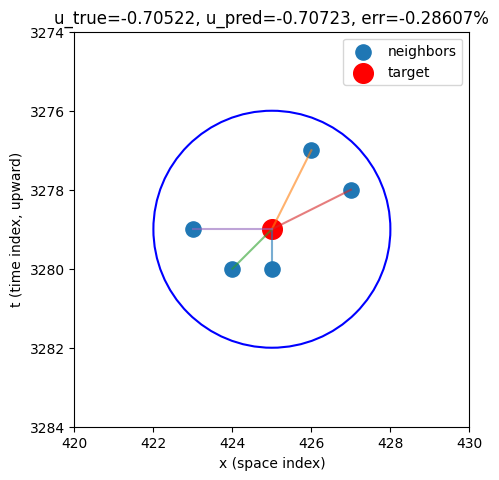

In [48]:
visualize_B_with_prediction(data, model, R=3, k=5, device="cpu")
